# Parameter Recovery (Fully Simulated)

Same workflow as `parameter_recovery.ipynb`, except the dataset is generated
*entirely* by the Cython `simulate_addm` function instead of pulling covariates
(r1/r2, saccade arrays, d_data, flag) from the empirical monkey data.

1. Pick ground-truth `(eta, kappa, a, b, x0)` (from a saved trace's posterior means)
2. Call `simulate_addm` to produce a synthetic dataset, including covariates and RT/choice
3. Fit the same PyMC model to the simulated data
4. Compare recovered posteriors to the ground-truth values
5. PPC stratified by (r1 - r2)

In [1]:
import os
import sys
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pymc as pm
import pytensor.tensor as pt
from pytensor.graph.op import Op

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

from efficient_fpt_jax.multi_stage import get_addm_fptd_jax_fast, pad_sacc_array_safely
from efficient_fpt.addm import _build_mu_data_padded, simulate_addm
from efficient_fpt.addm_simulator_cy import simulate_addm_batch_cy

In [2]:
# trace_emp = az.from_netcdf(TRACE_PATH)

# TRUE_PARAMS = {
#     'eta'  : float(trace_emp.posterior['eta'].mean()),
#     'kappa': float(trace_emp.posterior['kappa'].mean()),
#     'a'    : float(trace_emp.posterior['a'].mean()),
#     'b'    : float(trace_emp.posterior['b'].mean()),
#     'x0'   : float(trace_emp.posterior['x0'].mean()),
# }

TRUE_PARAMS = {
    'eta'  : 0.3,
    'kappa': 0.5,
    'a'    : 2.0,
    'b'    : 0.3,
    'x0'   : 0.0,
}


print("Ground-truth parameters (posterior means from empirical fit):")
for k, v in TRUE_PARAMS.items():
    print(f"  {k:6s} = {v:.6f}")

Ground-truth parameters (posterior means from empirical fit):
  eta    = 0.300000
  kappa  = 0.500000
  a      = 2.000000
  b      = 0.300000
  x0     = 0.000000


## Configuration

In [3]:
sigma    = 1.0   # Fixed noise (unidentifiable with other params)

TRUNC_NUM   = 6
N_DRAWS     = 500
N_TUNE      = 200
N_CHAINS    = 4
RANDOM_SEED = 42

TRACE_PATH  = "/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/traces/trace_monk1_newdur.nc"

# --- Forward simulation settings ---
N_TRIALS    = 4500
SIM_SEED    = 7
SIM_DT      = 1e-4
SIM_MAX_T   = TRUE_PARAMS['a'] / TRUE_PARAMS['b'] if TRUE_PARAMS['b'] > 0.0 else 10.0
GAMMA_SHAPE = 6.0
GAMMA_SCALE = 0.1
R_RANGE     = (1, 6)

## Helper functions (copied from parameter_recovery.ipynb)

In [4]:
def make_jax_arrays(data, max_d):
    jax_sacc = jnp.array(data['sacc'])
    jax_d    = jnp.array(data['length_data'])
    jax_sacc_safe = vmap(
        lambda s, d: pad_sacc_array_safely(s, d, max_d)
    )(jax_sacc, jax_d)
    return dict(
        rt       = jnp.array(data['rt']),
        choice   = jnp.array(data['choice']),
        d        = jax_d,
        r1       = jnp.array(data['r1']),
        r2       = jnp.array(data['r2']),
        flag     = jnp.array(data['flag_data']),
        sacc_safe= jax_sacc_safe,
    )


def compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d):
    mu1 = kappa * (r1 - eta * r2)
    mu2 = kappa * (eta * r1 - r2)
    indices = jnp.arange(max_d)
    return jnp.where((indices % 2) == flag, mu1, mu2)


def jax_loglik_single(rt, choice, d, r1, r2, flag, sacc_safe,
                      eta, kappa, a, b, x0, sigma, max_d, trunc_num):
    mu_array = compute_mu_arrays_jax(eta, kappa, r1, r2, flag, max_d)
    fptd = get_addm_fptd_jax_fast(
        rt, d, mu_array, sacc_safe, sigma, a, b, x0, choice,
        order=30, trunc_num=trunc_num
    )
    return jnp.log(jnp.maximum(fptd, 1e-300))


def make_jax_likelihood(jax_data, sigma, max_d, trunc_num):
    def loglik_batch(eta, kappa, a, b, x0):
        per_trial = vmap(
            lambda rt, choice, d, r1, r2, flag, sacc_safe: jax_loglik_single(
                rt, choice, d, r1, r2, flag, sacc_safe,
                eta, kappa, a, b, x0, sigma, max_d, trunc_num,
            )
        )(
            jax_data['rt'], jax_data['choice'], jax_data['d'],
            jax_data['r1'], jax_data['r2'], jax_data['flag'],
            jax_data['sacc_safe'],
        )
        return jnp.sum(per_trial)

    loglik_jit  = jit(loglik_batch)
    grad_loglik = jit(grad(loglik_batch, argnums=(0, 1, 2, 3, 4)))
    return loglik_jit, grad_loglik


class LogLikeJAXGrad(Op):
    itypes = [pt.dvector]
    otypes = [pt.dvector]

    def __init__(self, grad_fn):
        self.grad_fn = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        grads = self.grad_fn(eta, kappa, a, b, x0)
        outputs[0][0] = np.array([float(g) for g in grads], dtype="float64")


class LogLikeJAX(Op):
    itypes = [pt.dvector]
    otypes = [pt.dscalar]

    def __init__(self, loglik_fn, grad_fn):
        self.loglik_fn = loglik_fn
        self.grad_fn   = grad_fn

    def perform(self, node, inputs, outputs):
        (theta,) = inputs
        eta, kappa, a, b, x0 = theta
        outputs[0][0] = np.array(float(self.loglik_fn(eta, kappa, a, b, x0)), dtype="float64")

    def grad(self, inputs, output_grads):
        (theta,)  = inputs
        (g_out,)  = output_grads
        grads = LogLikeJAXGrad(self.grad_fn)(theta)
        return [g_out * grads]


from pytensor.link.jax.dispatch import jax_funcify

@jax_funcify.register(LogLikeJAX)
def jax_funcify_LogLikeJAX(op, **kwargs):
    loglik_fn = op.loglik_fn
    def loglik_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return loglik_fn(eta, kappa, a, b, x0)
    return loglik_jax


@jax_funcify.register(LogLikeJAXGrad)
def jax_funcify_LogLikeJAXGrad(op, **kwargs):
    grad_fn = op.grad_fn
    def grad_jax(theta):
        eta, kappa, a, b, x0 = theta[0], theta[1], theta[2], theta[3], theta[4]
        return jnp.stack(grad_fn(eta, kappa, a, b, x0))
    return grad_jax


def make_pymc_model(loglike_op, M):
    with pm.Model() as model:
        eta     = pm.Beta("eta",   alpha=2.0, beta=2.0)
        kappa   = pm.Gamma("kappa", alpha=2.0, beta=4.0)
        # a_param = 3.008039
        a_param = pm.Gamma("a",     alpha=4.0, beta=2.0)
        # b_raw = pm.Normal("b_raw", mu=1.5, sigma=0.5)
        b_raw = pm.Beta("b_raw", alpha=2.0, beta=2.0)
        b_param = pm.Deterministic("b", b_raw * a_param / M * 0.95)

        x0_raw  = pm.Beta("x0_raw", alpha=2.0, beta=2.0)
        x0_param= pm.Deterministic("x0", -a_param + 2.0 * a_param * x0_raw)

        theta = pt.stack([eta, kappa, a_param, b_param, x0_param])
        pm.Potential("loglik", loglike_op(theta))
    return model

/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Extract ground-truth parameters from a saved trace

## 2. Forward-simulate a fully synthetic dataset

All covariates (r1, r2, sacc, d_data, flag) come from `simulate_addm`.

In [5]:
# Warm up
_ = simulate_addm(
    n_trials=10, random_state=0,
    eta=TRUE_PARAMS['eta'], kappa=TRUE_PARAMS['kappa'], sigma=sigma,
    a=TRUE_PARAMS['a'], b=TRUE_PARAMS['b'], x0=TRUE_PARAMS['x0'],
    gamma_shape=GAMMA_SHAPE, gamma_scale=GAMMA_SCALE,
    r_range=R_RANGE, dt=SIM_DT, max_t=SIM_MAX_T,
)

t0 = time.perf_counter()
sim = simulate_addm(
    n_trials=N_TRIALS, random_state=SIM_SEED,
    eta=TRUE_PARAMS['eta'], kappa=TRUE_PARAMS['kappa'], sigma=sigma,
    a=TRUE_PARAMS['a'], b=TRUE_PARAMS['b'], x0=TRUE_PARAMS['x0'],
    gamma_shape=GAMMA_SHAPE, gamma_scale=GAMMA_SCALE,
    r_range=R_RANGE, dt=SIM_DT, max_t=SIM_MAX_T,
)
sim_time = time.perf_counter() - t0
print(f"simulate_addm: {sim_time:.4f}s for {N_TRIALS} trials")

sim_rt     = sim['rt']
sim_choice = sim['choice']
terminated = sim_rt > 0
print(f"Terminated: {terminated.sum()} / {N_TRIALS}  ({100*terminated.mean():.1f}%)")
print(f"Choice +1 (among terminated): {(sim_choice[terminated] == 1).mean():.3f}")
print(f"max d_data : {int(sim['d_data'].max())}")
print(f'max RT', sim_rt.max())

simulate_addm: 3.0823s for 4500 trials
Terminated: 4500 / 4500  (100.0%)
Choice +1 (among terminated): 0.501
max d_data : 11
max RT 5.050450000001568


(array([ 802., 1113., 1047.,  688.,  411.,  256.,  115.,   46.,   13.,
           7.,    2.]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 <BarContainer object of 11 artists>)

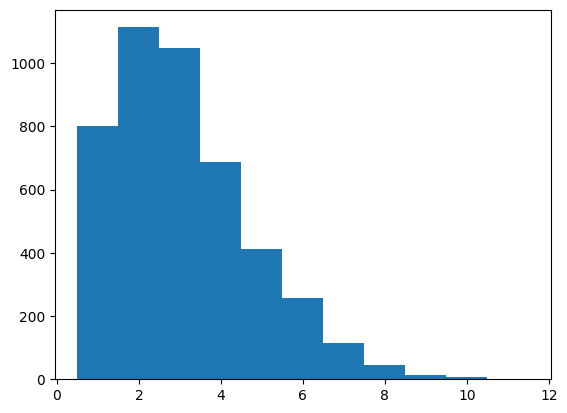

In [6]:
unique_nums = np.unique(sim['d_data'])
plt.hist(sim['d_data'], bins=np.arange(unique_nums.min() - 0.5, unique_nums.max() + 1.5, 1))


In [7]:
sim['d_data']

array([2, 8, 3, ..., 6, 1, 3], shape=(4500,), dtype=int32)

max d 11


(array([147., 242., 235., 160., 104.,  71.,  21.,   9.,   9.,   1.,   1.]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 <BarContainer object of 11 artists>)

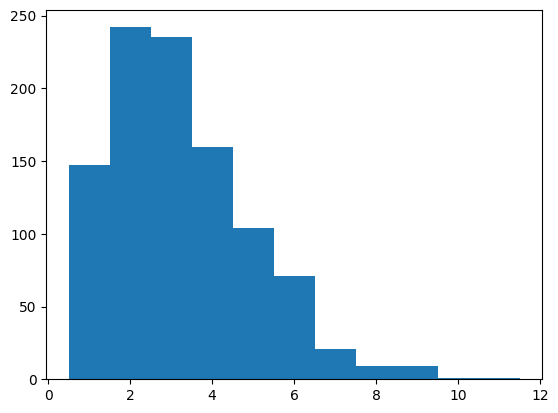

In [8]:
# Compare d distribution between simulated data and empirical data

simulated_data = np.load("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/traces/simulated_params/sim_00000/simulated_data.npz")
unique_d_sim = np.unique(simulated_data['d_data'])
print('max d', max(unique_d_sim))
plt.hist(simulated_data['d_data'], bins=np.arange(unique_d_sim.min() - 0.5, unique_d_sim.max() + 1.5, 1))

In [9]:
simulated_data['d_data']

array([ 4,  4,  2,  5,  2,  5,  4,  1,  2,  4,  4,  4,  2, 10,  2,  7,  1,
        3,  5,  2,  4,  2,  2,  2,  9,  6,  3,  5,  3,  3,  5,  5,  5,  4,
        2,  5,  3,  4,  2,  1,  1,  2,  1,  2,  5,  1,  1,  4,  2,  1,  2,
        3,  3,  2,  2,  2,  6,  5,  2,  4,  1,  3,  4,  1,  2,  3,  5,  2,
        3,  4,  1,  1,  2,  2,  5,  3,  1,  4,  1,  3,  1,  7,  5,  3,  3,
        1,  2,  3,  3,  5,  2,  5,  4,  3,  1,  3,  3,  6,  2,  7,  8,  4,
        2,  4,  5,  3,  1,  3,  1,  3,  2,  3,  3,  3,  7,  4,  3,  2,  2,
        2,  5,  1,  3,  1,  2,  2,  1,  7,  2,  4,  6,  3,  2,  6,  9,  5,
        1,  3,  4,  2,  5,  1,  1,  1,  6,  2,  4,  2,  8,  1,  2,  3,  4,
        2,  4,  3,  2,  3,  2,  6,  6,  4,  5,  1,  3,  2,  3,  3,  5,  2,
        2,  3,  2,  5,  1,  3,  4,  6,  6,  3,  5,  3,  2,  6,  6,  4,  5,
        3,  2,  2,  2,  4,  5,  2,  3,  3,  4,  2,  1,  3,  3,  2,  3,  6,
        2,  2,  2,  1,  2,  4,  3,  4,  2,  2,  3,  5,  3,  3,  1,  6,  2,
        5,  3,  2,  9,  4

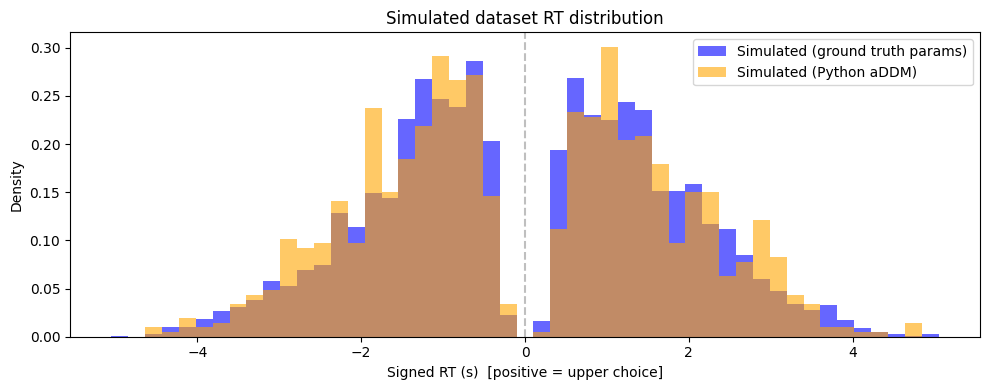

In [10]:
# Quick visual sanity check
sim_signed = sim_rt * sim_choice
sim_py_signed = simulated_data['rt_data'] * simulated_data['choice_data']
xmax = float(np.abs(sim_signed).max())
bins = np.linspace(-xmax, xmax, 50)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sim_signed, bins=bins, density=True, alpha=0.6, color='blue',
        label='Simulated (ground truth params)')
ax.hist(sim_py_signed, bins=bins, density=True, alpha=0.6, color='orange',
        label='Simulated (Python aDDM)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Signed RT (s)  [positive = upper choice]')
ax.set_ylabel('Density')
ax.set_title('Simulated dataset RT distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
rng = np.random.default_rng(SIM_SEED)
avg_fixation = GAMMA_SHAPE * GAMMA_SCALE
n_fixations_budget = int(SIM_MAX_T / avg_fixation) + 50 

fixations  = rng.gamma(GAMMA_SHAPE, GAMMA_SCALE, n_fixations_budget)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
print(len(sacc_array))
sacc_array = sacc_array[sacc_array < SIM_MAX_T]
print(len(sacc_array))

62
14


In [12]:
fixations  = rng.gamma(GAMMA_SHAPE, GAMMA_SCALE, 100)
sacc_array = np.insert(np.cumsum(fixations), 0, 0)
print(len(sacc_array))
sacc_array = sacc_array[sacc_array < SIM_MAX_T]
print(len(sacc_array))

101
12


In [13]:
# import json
# from pathlib import Path
# from typing import Dict

# # Python aDDM simulator 
# # ── Simulate dataset (pure-Python aDDModel via simulate_fpt_datum) ────────────
# # Mirrors the simulation used in param_recovery_main.py, which avoids the
# # heavily zero-padded saccade arrays produced by the Cython simulator.
# from efficient_fpt.models import DDModel, piecewise_const_func
# from efficient_fpt.utils import get_alternating_mu_array


# class aDDModel(DDModel):
#     """Single-trial attentional DDM."""
#     def __init__(self, mu1, mu2, sacc_array, flag, sigma, a, b, x0):
#         super().__init__(x0)
#         self.mu1 = mu1
#         self.mu2 = mu2
#         self.sacc_array = sacc_array
#         self.flag = flag
#         self.d = len(sacc_array)
#         self.mu_array = get_alternating_mu_array(mu1, mu2, self.d, flag)
#         self.sigma = sigma
#         self.a = a
#         self.b = b

#     def drift_coeff(self, X, t):
#         return piecewise_const_func(t, self.mu_array, self.sacc_array)

#     def diffusion_coeff(self, X, t):
#         return self.sigma

#     @property
#     def is_update_vectorizable(self):
#         return True

#     def upper_bdy(self, t):
#         return self.a - self.b * t

#     def lower_bdy(self, t):
#         return -self.a + self.b * t


# def _simulate_trial_py(rng, eta, kappa, sigma, a, b, x0,
#                        t_max, shape, scale):
#     fixations  = rng.gamma(shape, scale, 100)
#     sacc_array = np.insert(np.cumsum(fixations), 0, 0)
#     sacc_array = sacc_array[sacc_array < t_max]

#     flag = rng.integers(0, 2)
#     r1   = rng.integers(1, 6)
#     r2   = rng.integers(1, 6)

#     mu1 = kappa * (r1 - eta * r2)
#     mu2 = kappa * (eta * r1 - r2)

#     model = aDDModel(mu1, mu2, sacc_array, flag, sigma, a, b, x0)
#     rt, choice = model.simulate_fpt_datum(dt=SIM_DT)

#     sacc_array = sacc_array[sacc_array < rt]
#     d = len(sacc_array)
#     mu_array = get_alternating_mu_array(mu1, mu2, d, flag)
#     return rt, int(choice), d, r1, r2, flag, mu1, mu2, mu_array, sacc_array


# a    = TRUE_PARAMS['a']
# b    = TRUE_PARAMS['b']
# tmax = a / b if b > 0.0 else 10.0

# rng = np.random.default_rng(SIM_SEED)
# trials = []
# t0 = time.perf_counter()
# for _ in range(N_TRIALS):
#     trials.append(_simulate_trial_py(
#         rng, TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'], sigma,
#         a, b, TRUE_PARAMS['x0'], tmax, GAMMA_SHAPE, GAMMA_SCALE,
#     ))
# print(f"Python simulation completed in {time.perf_counter() - t0:.2f}s")

# rt_data     = np.array([t[0] for t in trials], dtype=np.float64)
# choice_data = np.array([t[1] for t in trials], dtype=np.int32)
# d_data      = np.array([t[2] for t in trials], dtype=np.int32)
# r1_data     = np.array([t[3] for t in trials], dtype=np.float64)
# r2_data     = np.array([t[4] for t in trials], dtype=np.float64)
# flag_data   = np.array([t[5] for t in trials], dtype=np.int32)
# mu1_data    = np.array([t[6] for t in trials], dtype=np.float64)
# mu2_data    = np.array([t[7] for t in trials], dtype=np.float64)

# # Drop trials that did not terminate
# terminated = rt_data > 0
# if not np.all(terminated):
#     keep = np.where(terminated)[0]
#     rt_data = rt_data[keep]; choice_data = choice_data[keep]
#     d_data = d_data[keep]; r1_data = r1_data[keep]; r2_data = r2_data[keep]
#     flag_data = flag_data[keep]
#     trials = [trials[i] for i in keep]

# max_d = int(d_data.max())
# mu_data_padded   = np.zeros((len(trials), max_d), dtype=np.float64)
# sacc_data_padded = np.zeros((len(trials), max_d), dtype=np.float64)
# for i, t in enumerate(trials):
#     di = t[2]
#     mu_data_padded[i, :di]   = t[8]
#     sacc_data_padded[i, :di] = t[9]

# sacc_data_padded = np.ascontiguousarray(sacc_data_padded)

# print(f"  Trials: {len(rt_data)}, max stages: {max_d}")
# print(f"  RT range: [{rt_data.min():.4f}, {rt_data.max():.4f}]")
# print(f"  Upper choices: {np.sum(choice_data == 1)} ({100*np.mean(choice_data == 1):.1f}%)")


# def save_simulated_data(sim_id: int, true_params: Dict[str, float],
#                         rt_data: np.ndarray, choice_data: np.ndarray,
#                         d_data: np.ndarray, r1_data: np.ndarray, r2_data: np.ndarray,
#                         flag_data: np.ndarray, mu_data_padded: np.ndarray,
#                         sacc_data_padded: np.ndarray, mu1_data: np.ndarray,
#                         mu2_data: np.ndarray,
#                         output_dir: Path) -> None:
#     """Save simulated data and ground-truth parameters for one simulation run."""
#     sim_params_dir = output_dir / "simulated_params" / f"sim_{sim_id:05d}"
#     sim_params_dir.mkdir(parents=True, exist_ok=True)

#     true_params_path = sim_params_dir / "true_params.json"
#     with open(true_params_path, 'w') as f:
#         json.dump({k: float(v) for k, v in true_params.items()}, f, indent=2)

#     np.savez(
#         sim_params_dir / "simulated_data.npz",
#         rt_data=rt_data,
#         choice_data=choice_data,
#         # saved as both keys so downstream code using either name works
#         d_data=d_data,
#         length_data=d_data,
#         r1_data=r1_data,
#         r2_data=r2_data,
#         flag_data=flag_data,
#         mu_data_padded=mu_data_padded,
#         sacc_data_padded=sacc_data_padded,
#         mu1_data=mu1_data,
#         mu2_data=mu2_data,
#     )
#     print(f"Simulated data saved to {sim_params_dir}/")

# save_simulated_data(
#     sim_id=0, true_params=TRUE_PARAMS,
#     rt_data=rt_data, choice_data=choice_data,
#     d_data=d_data, r1_data=r1_data, r2_data=r2_data,
#     flag_data=flag_data, mu_data_padded=mu_data_padded,
#     sacc_data_padded=sacc_data_padded,
#     mu1_data=mu1_data, mu2_data=mu2_data,
#     output_dir=Path("/users/azhan378/data/azhang/efficient-fpt/examples/example8_empirical/traces"),
# )

In [14]:
from numpy.typing import NDArray
rng = np.random.default_rng(SIM_SEED)

def _generate_fixation_sequences(
    rng: np.random.Generator,
    n_trials: int,
    max_t: float,
    gamma_shape: float,
    gamma_scale: float,
) -> tuple[NDArray, NDArray, int]:
    """Generate padded saccade-time arrays and per-trial stage counts.

    Returns (sacc_data_padded, d_data, max_d).
    """
    avg_fixation = gamma_shape * gamma_scale
    n_fixations_budget = int(max_t / avg_fixation) + 50
    n_fixations_budget = max(n_fixations_budget, 10)
    print(n_fixations_budget)
    durations = rng.gamma(gamma_shape, gamma_scale, (n_trials, n_fixations_budget))
    cum_times = np.cumsum(durations, axis=1)
    sacc_times = np.concatenate(
        [np.zeros((n_trials, 1), dtype=np.float64), cum_times], axis=1
    )
   
    within_budget = sacc_times < max_t
    d_data = within_budget.sum(axis=1).astype(np.int32)
    if np.any(d_data < 1):
        raise ValueError(
            "Some trials have 0 fixations before max_t. "
            "Increase max_t or check gamma_shape/gamma_scale."
        )

    max_d = int(d_data.max())
    sacc_data_padded = np.ascontiguousarray(
        sacc_times[:, :max_d], dtype=np.float64
    )
    return sacc_data_padded, d_data, max_d
sacc_sim, d_da_test, max_d_test = _generate_fixation_sequences(rng, 500, SIM_MAX_T, GAMMA_SHAPE, GAMMA_SCALE)
d_da_test
sacc_sim
# max_d_test

61


array([[0.        , 0.56695955, 1.07084135, ..., 5.87269294, 6.42789231,
        6.70278371],
       [0.        , 0.65750256, 1.450538  , ..., 6.80609522, 7.3759397 ,
        7.86834291],
       [0.        , 0.18768101, 0.40301228, ..., 5.92943495, 6.4943518 ,
        7.57771346],
       ...,
       [0.        , 1.42624372, 1.88440202, ..., 7.45634943, 7.72991497,
        8.24817343],
       [0.        , 1.19953318, 2.09835721, ..., 7.81474931, 8.28563053,
        8.65189759],
       [0.        , 0.20896937, 0.70322815, ..., 5.69593384, 6.60226758,
        6.8781723 ]], shape=(500, 15))

In [15]:
for row in sim['sacc_data_padded']: 
    new_row = row[row != 0]
    if len(new_row) > 15:
        print(new_row)

In [16]:
# Build a data dict from the simulation output (terminated trials only)
mask = terminated

max_d = int(sim['d_data'].max())
sacc_padded = sim['sacc_data_padded']
if sacc_padded.shape[1] < max_d:
    pad = np.zeros((sacc_padded.shape[0], max_d - sacc_padded.shape[1]), dtype=np.float64)
    sacc_padded = np.concatenate([sacc_padded, pad], axis=1)
else:
    sacc_padded = sacc_padded[:, :max_d]

data_sim = dict(
    rt          = sim_rt[mask].astype(np.float64),
    choice      = sim_choice[mask].astype(np.int32),
    r1          = sim['r1'][mask].astype(np.float64),
    r2          = sim['r2'][mask].astype(np.float64),
    sacc        = np.ascontiguousarray(sacc_padded[mask], dtype=np.float64),
    length_data = sim['d_data'][mask].astype(np.int32),
    flag_data   = sim['flag'][mask].astype(np.int32),
)

# data_sim = dict(
#     rt          = rt_data[mask].astype(np.float64),
#     choice      = choice_data[mask].astype(np.int32),
#     r1          = r1_data[mask].astype(np.float64),
#     r2          = r2_data[mask].astype(np.float64),
#     sacc        = np.ascontiguousarray(sacc_data_padded[mask], dtype=np.float64),
#     length_data = d_data[mask].astype(np.int32),
#     flag_data   = flag_data[mask].astype(np.int32),
# )

print(f"Synthetic dataset: {len(data_sim['rt'])} trials, max_d = {max_d}")

Synthetic dataset: 4500 trials, max_d = 11


In [17]:
data_sim['sacc']

array([[0.        , 0.77005398, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.15857006, 0.50139002, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.49351603, 0.84092191, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.49054779, 0.69445763, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.25712577, 0.68203835, ..., 0.        , 0.        ,
        0.        ]], shape=(4500, 11))

In [18]:
# # Quick visual sanity check
# sim_signed = data_sim['rt'] * data_sim['choice']
# sim_py_signed = rt_data * choice_data
# xmax = float(np.abs(sim_signed).max())
# bins = np.linspace(-xmax, xmax, 50)

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.hist(sim_signed, bins=bins, density=True, alpha=0.6, color='blue',
#         label='Simulated (ground truth params)')
# ax.hist(sim_py_signed, bins=bins, density=True, alpha=0.6, color='orange',
#         label='Simulated (Python aDDM)')
# ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
# ax.set_xlabel('Signed RT (s)  [positive = upper choice]')
# ax.set_ylabel('Density')
# ax.set_title('Simulated dataset RT distribution')
# ax.legend()
# plt.tight_layout()
# plt.show()

## 3. Fit the PyMC model to the simulated data

In [19]:
print(f"Fitting on {len(data_sim['rt'])} simulated trials")

jax_data_sim = make_jax_arrays(data_sim, max_d)
loglik_sim, grad_sim = make_jax_likelihood(jax_data_sim, sigma, max_d, TRUNC_NUM)

print("Warming up JIT...")
t0_ = time.time()
_ = loglik_sim(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
               TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
_ = grad_sim(TRUE_PARAMS['eta'], TRUE_PARAMS['kappa'],
             TRUE_PARAMS['a'], TRUE_PARAMS['b'], TRUE_PARAMS['x0'])
print(f"JIT warm-up: {time.time()-t0_:.1f}s")

M_sim   = float(data_sim['rt'].max())
op_sim  = LogLikeJAX(loglik_sim, grad_sim)
model_sim = make_pymc_model(op_sim, M_sim)
print("Model built.", model_sim.point_logps())

Fitting on 4500 simulated trials
Warming up JIT...
JIT warm-up: 6.7s


/oscar/data/frankmj/azhang/efficient-fpt/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Model built. {'eta': np.float64(-0.98), 'kappa': np.float64(-0.61), 'a': np.float64(-0.25), 'b_raw': np.float64(-0.98), 'x0_raw': np.float64(-0.98), 'loglik': np.float64(-5895.61)}


In [20]:
print(f"Sampling | {N_DRAWS} draws, {N_TUNE} tune, {N_CHAINS} chains")
print(f"Started: {datetime.datetime.now().strftime('%H:%M:%S')}")

with model_sim:
    t_start = time.perf_counter()
    trace_sim = pm.sample(
        draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS,
        nuts_sampler="numpyro",
        random_seed=RANDOM_SEED,
        progressbar=True,
        return_inferencedata=True,
        # target_accept=0.90,
    )
    t_sample = time.perf_counter() - t_start

print(f"Finished: {datetime.datetime.now().strftime('%H:%M:%S')}")
print(f"Total sampling time: {t_sample:.1f}s")

Sampling | 500 draws, 200 tune, 4 chains
Started: 00:05:53


Compiling.. :   0%|          | 0/700 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/700 [00:11<?, ?it/s]


Running chain 0:   5%|▌         | 35/700 [01:04<16:47,  1.52s/it]


Running chain 0:  10%|█         | 70/700 [02:24<20:43,  1.97s/it]



Running chain 0:  20%|██        | 140/700 [05:26<20:49,  2.23s/it]


Running chain 0:  25%|██▌       | 175/700 [06:16<17:04,  1.95s/it]


Running chain 0:  35%|███▌      | 245/700 [07:26<10:43,  1.41s/it]




Running chain 0:  40%|████      | 280/700 [08:01<08:59,  1.28s/it]


Running chain 0:  45%|████▌     | 315/700 [08:31<07:22,  1.15s/it]


Running chain 0:  50%|█████     | 350/700 [09:06<06:25,  1.10s/it]



Running chain 0:  55%|█████▌    | 385/700 [09:36<05:25,  1.03s/it]




Running chain 0:  60%|██████    | 420/700 [10:09<04:39,  1.00it/s]


Running chain 0:  65%|██████▌   | 455/700 [10:42<04:01,  1.01it/s]

Running chain 0:  70%|███████   | 490/700 [11:15<03:23,  1.03it/s]





Running chain 0:  75%|███████▌  | 525/700 [11:48

Finished: 00:20:20
Total sampling time: 866.9s


## 4. Compare recovered posteriors to ground-truth

In [21]:
params = ['eta', 'kappa', 'b', 'x0','a']
print(az.summary(trace_sim, var_names=params))

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
eta    0.312  0.011   0.293    0.334      0.000      0.0    1373.0    1156.0   
kappa  0.508  0.007   0.495    0.522      0.000      0.0    1588.0    1711.0   
b      0.312  0.008   0.296    0.328      0.000      0.0    1022.0    1074.0   
x0    -0.024  0.013  -0.049   -0.000      0.000      0.0    2136.0    1170.0   
a      2.037  0.019   2.002    2.072      0.001      0.0    1311.0    1366.0   

       r_hat  
eta      1.0  
kappa    1.0  
b        1.0  
x0       1.0  
a        1.0  


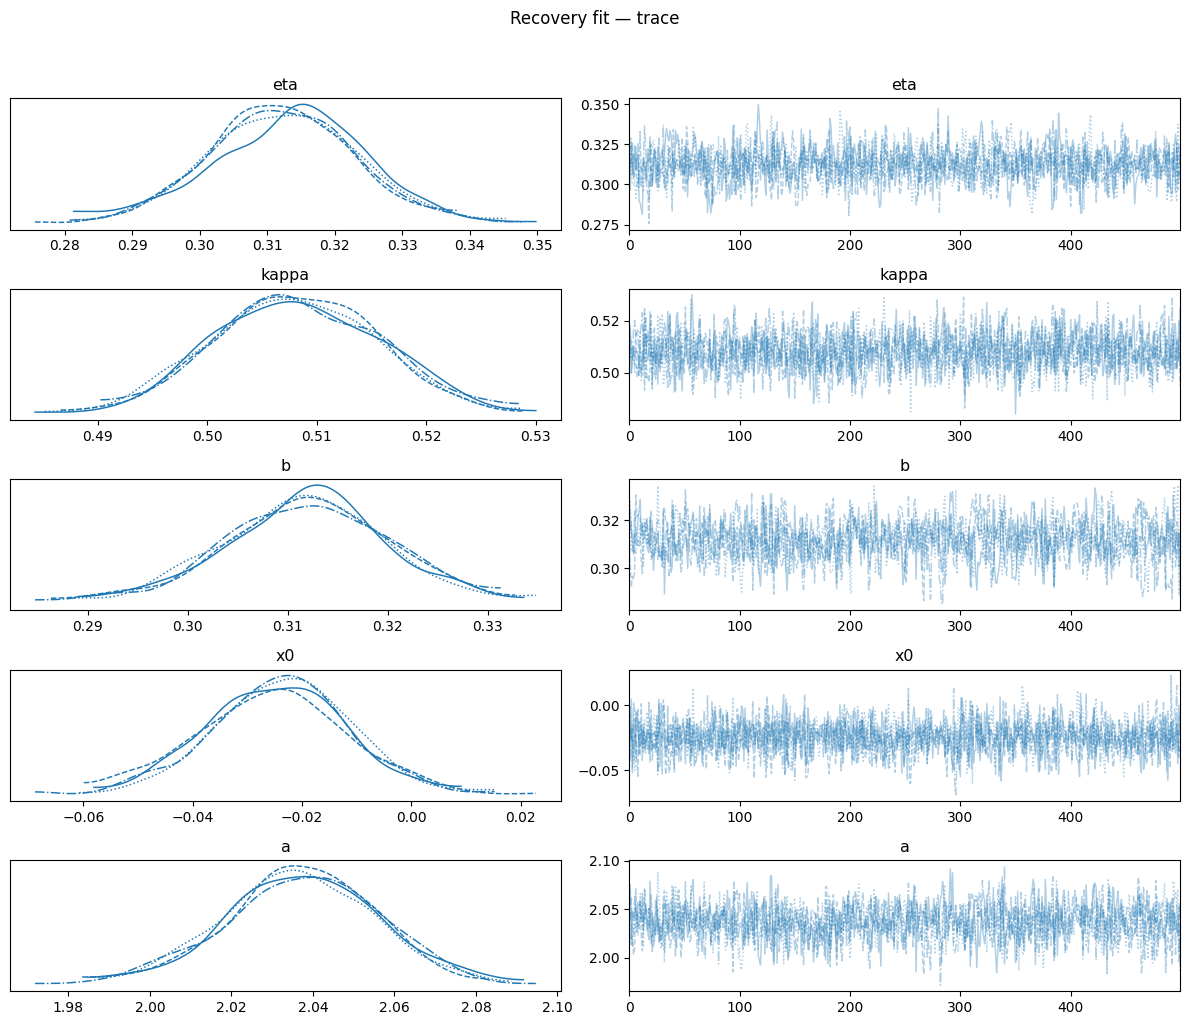

In [22]:
az.plot_trace(trace_sim, var_names=params)
plt.suptitle("Recovery fit \u2014 trace", y=1.02)
plt.tight_layout()
plt.show()

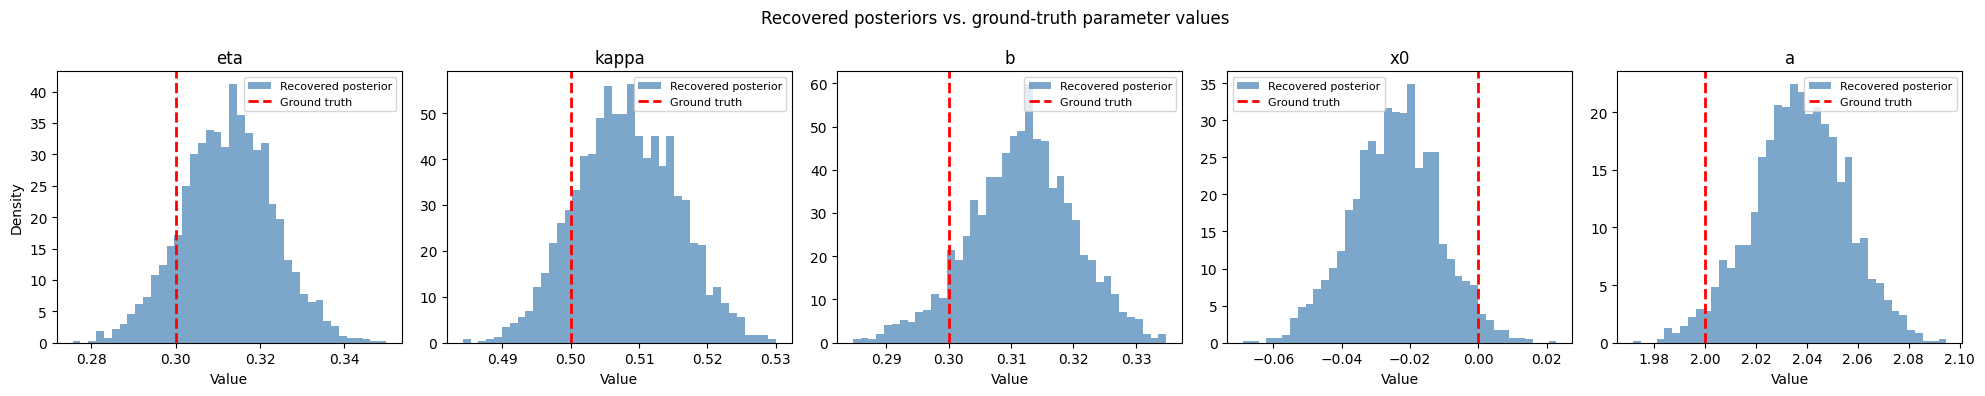

In [23]:
fig, axes = plt.subplots(1, len(params), figsize=(4 * len(params), 4))

for ax, p in zip(axes, params):
    samples = trace_sim.posterior[p].values.flatten()
    ax.hist(samples, bins=40, density=True, alpha=0.7, color='steelblue', label='Recovered posterior')
    ax.axvline(TRUE_PARAMS[p], color='red', linewidth=2, linestyle='--', label='Ground truth')
    ax.set_title(p)
    ax.set_xlabel('Value')
    if ax is axes[0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle("Recovered posteriors vs. ground-truth parameter values", fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
print(f"{'Parameter':>10s}  {'Ground truth':>14s}  {'Recovered mean':>14s}  {'Recovered 94% HDI':>22s}  {'Bias':>10s}")
print("-" * 80)

for p in params:
    samples = trace_sim.posterior[p].values.flatten()
    rec_mean = float(np.mean(samples))
    hdi = az.hdi(samples, hdi_prob=0.94)
    bias = rec_mean - TRUE_PARAMS[p]
    print(f"{p:>10s}  {TRUE_PARAMS[p]:>14.6f}  {rec_mean:>14.6f}"
          f"  [{hdi[0]:>9.6f}, {hdi[1]:>9.6f}]  {bias:>+10.6f}")

 Parameter    Ground truth  Recovered mean       Recovered 94% HDI        Bias
--------------------------------------------------------------------------------
       eta        0.300000        0.312429  [ 0.293023,  0.334245]   +0.012429
     kappa        0.500000        0.508156  [ 0.494715,  0.521766]   +0.008156
         b        0.300000        0.311784  [ 0.296052,  0.328245]   +0.011784
        x0        0.000000       -0.024393  [-0.049182, -0.000256]   -0.024393
         a        2.000000        2.037023  [ 2.001663,  2.071611]   +0.037023


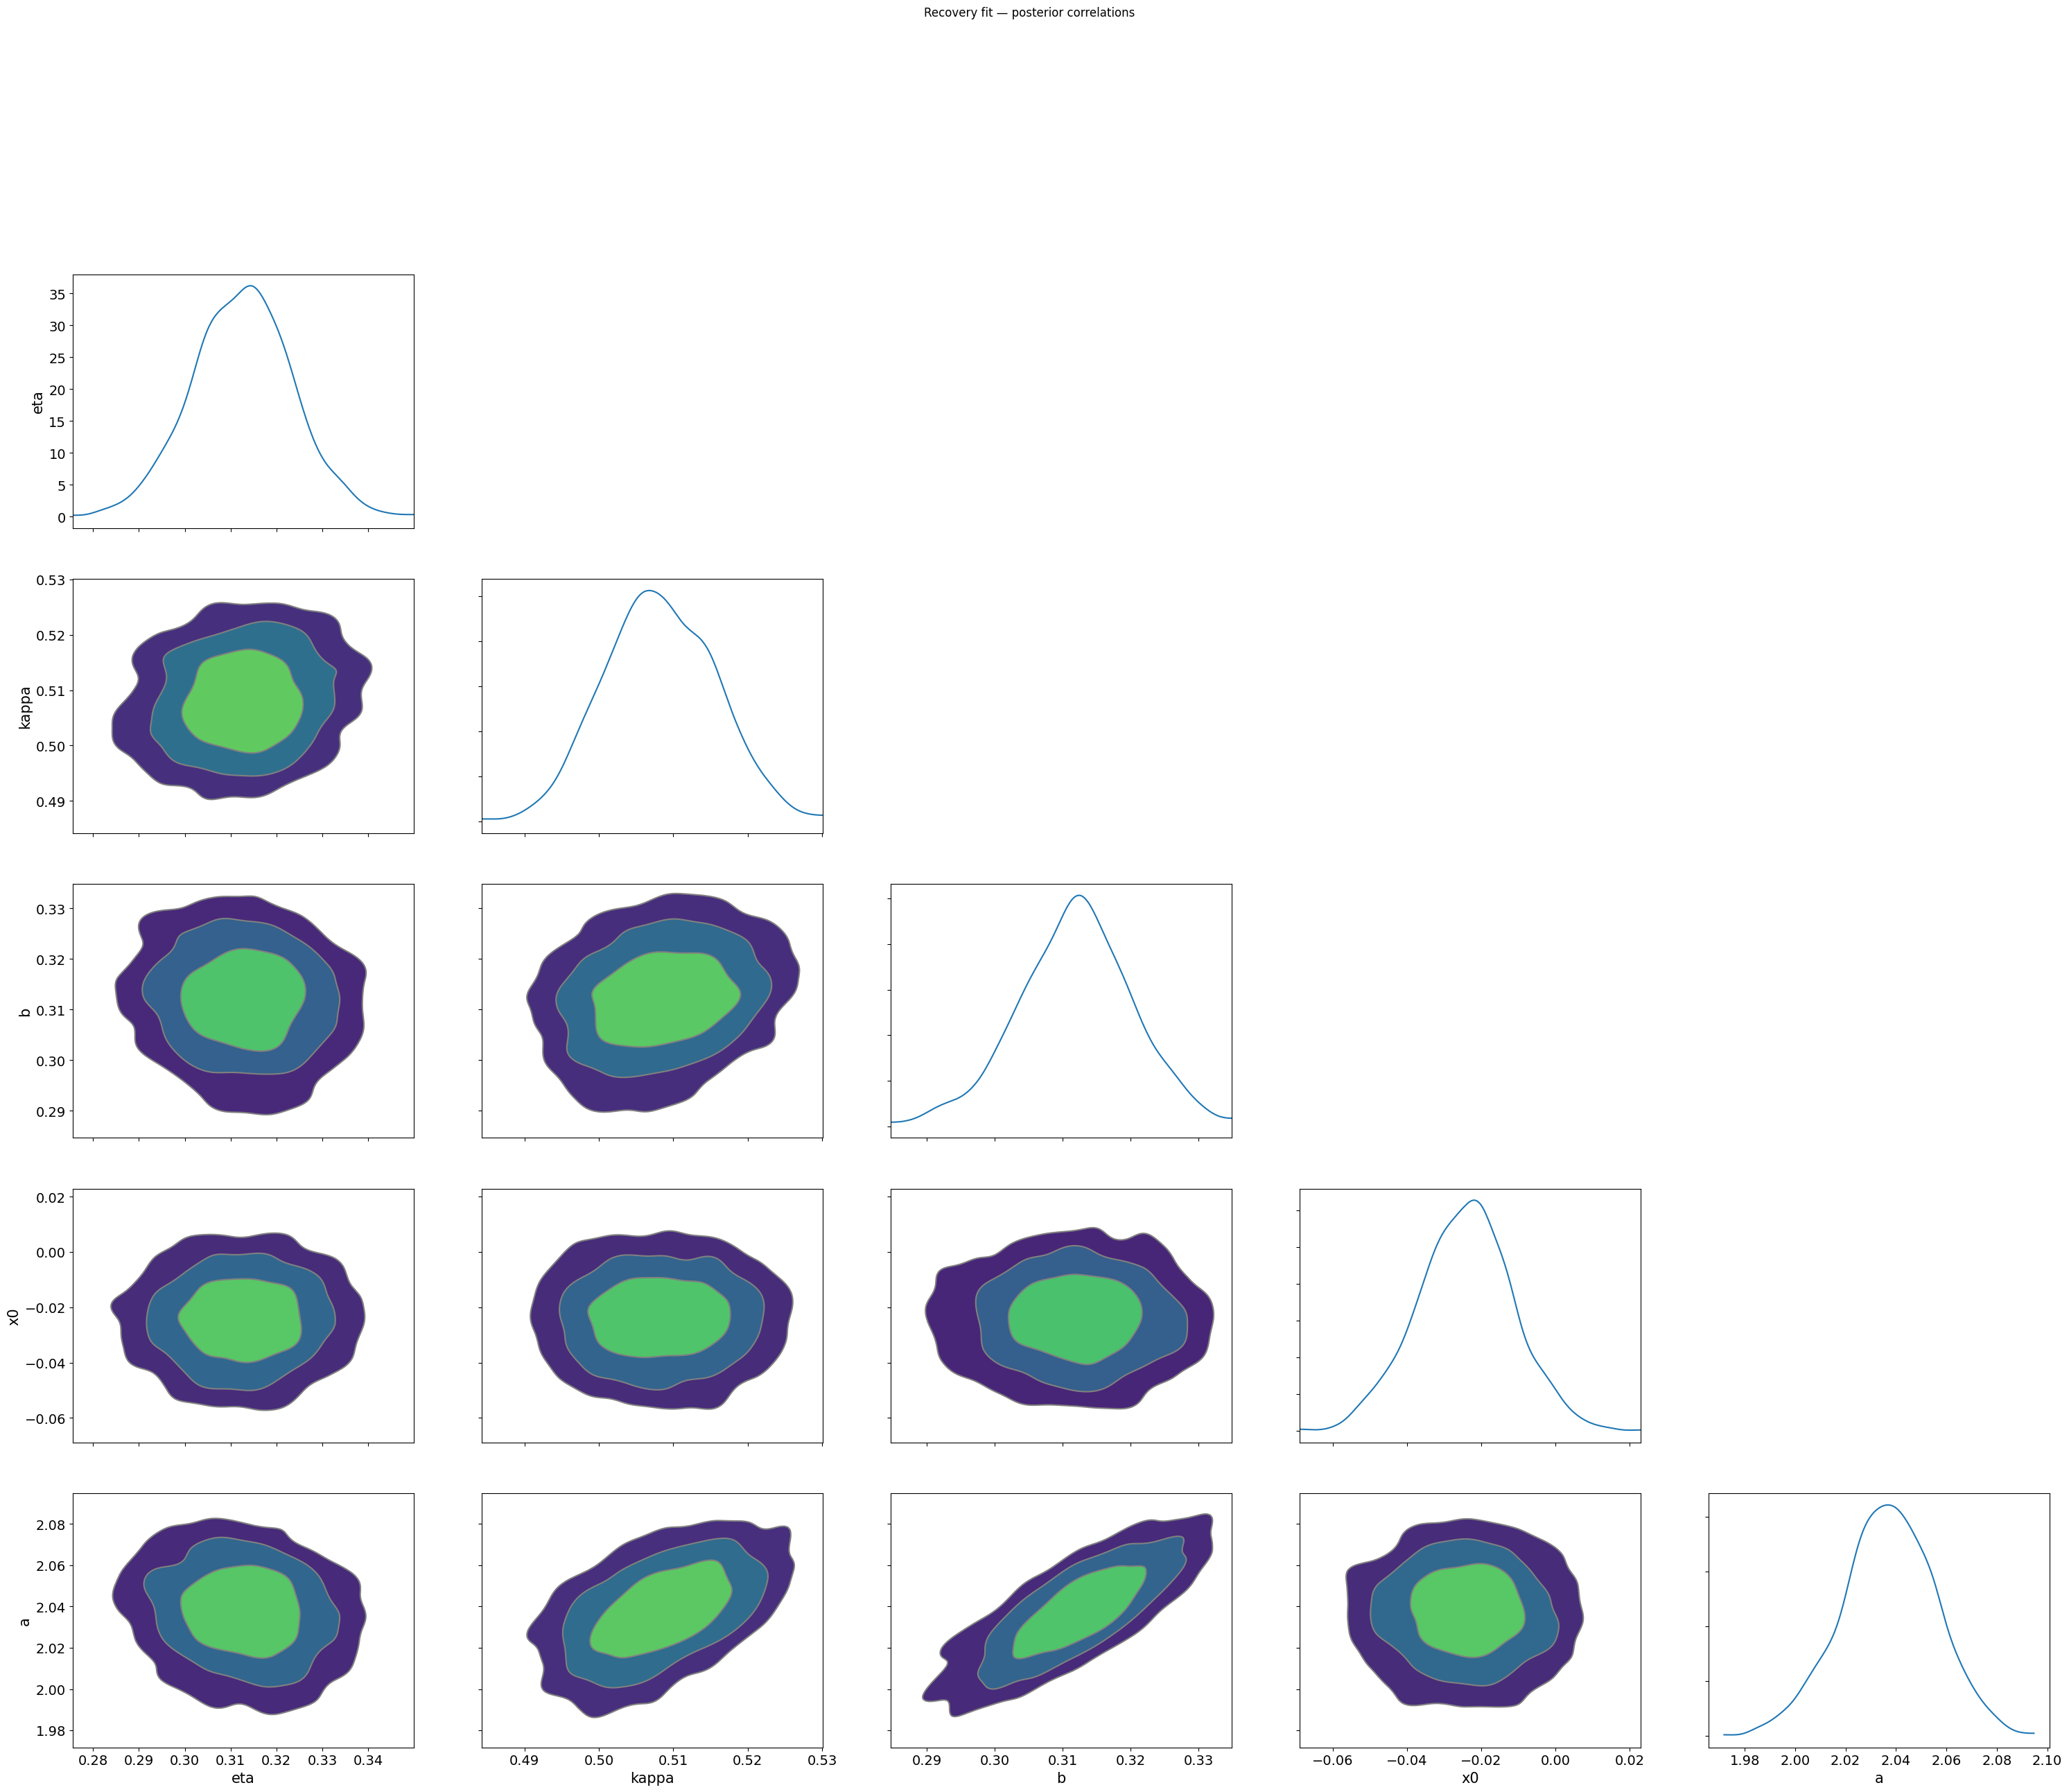

In [25]:
az.plot_pair(trace_sim, var_names=params, kind='kde', marginals=True)
plt.suptitle("Recovery fit \u2014 posterior correlations", y=1.02)
plt.show()

## 5. Posterior predictive check stratified by (r1 - r2)

In [26]:
from scipy.stats import gaussian_kde


def plot_ppc_by_diff(trace, data, monkey_label,
                     n_ppc_draws=100, ci_lo=2.5, ci_hi=97.5,
                     plot_kind='hist_pooled', seed=2024,
                     n_hist_bins=50,
                     dt=1e-4, max_t=10.0, sigma=1.0, max_d=4):
    """Posterior predictive check stratified by (r1 - r2) difference."""
    r1       = data['r1']
    r2       = data['r2']
    sacc     = data['sacc']
    length_d = data['length_data']
    flag_d   = data['flag_data']
    emp_rt   = data['rt']
    emp_ch   = data['choice']

    post    = trace.posterior
    eta_s   = post['eta'].values.reshape(-1)
    kappa_s = post['kappa'].values.reshape(-1)
    b_s     = post['b'].values.reshape(-1)
    x0_s    = post['x0'].values.reshape(-1)

    rng_pick = np.random.default_rng(seed)
    n_post   = eta_s.size
    draw_idx = rng_pick.choice(n_post, size=min(n_ppc_draws, n_post), replace=False)
    print(f"{monkey_label}: using {len(draw_idx)} posterior draws from {n_post} total.")

    diffs        = (r1 - r2).astype(int)
    unique_diffs = np.sort(np.unique(diffs))
    print("  Unique r1-r2 differences:", unique_diffs.tolist())

    emp_signed_by_bin = {}
    x_grids           = {}
    for d in unique_diffs:
        mask = diffs == d
        ok   = mask & (emp_rt > 0)
        es   = emp_rt[ok] * emp_ch[ok]
        emp_signed_by_bin[int(d)] = es
        lim = float(np.abs(es).max() * 1.2) if len(es) else 1.0
        x_grids[int(d)] = np.linspace(-lim, lim, 300)

    pooled_mode = (plot_kind == 'hist_pooled')

    sim_pooled_by_bin = {int(d): [] for d in unique_diffs}
    kde_curves_by_bin = {int(d): [] for d in unique_diffs}
    rng_sim = np.random.default_rng(seed + 1)

    for k, idx in enumerate(draw_idx):
        eta_k   = float(eta_s[idx])
        kappa_k = float(kappa_s[idx])
        a_k     = 3.0
        b_k     = float(b_s[idx])
        x0_k    = float(x0_s[idx])

        mu1_k = kappa_k * (r1 - eta_k * r2)
        mu2_k = kappa_k * (eta_k * r1 - r2)
        mu_data_k = _build_mu_data_padded(
            mu1_k.astype(np.float64), mu2_k.astype(np.float64),
            length_d, flag_d, max_d,
        )
        budget_time_k  = min(a_k / b_k, max_t) if b_k > 0 else max_t
        budget_steps_k = int(budget_time_k / dt) + 1

        for d in unique_diffs:
            mask  = diffs == d
            n_bin = int(mask.sum())
            if n_bin == 0:
                continue
            gnoise = np.ascontiguousarray(
                rng_sim.standard_normal((n_bin, budget_steps_k), dtype=np.float64)
            )
            sim_rt_k, sim_ch_k = simulate_addm_batch_cy(
                np.ascontiguousarray(mu_data_k[mask]),
                np.ascontiguousarray(sacc[mask]),
                np.ascontiguousarray(length_d[mask]),
                sigma, a_k, b_k, x0_k, dt, budget_time_k, gnoise,
            )
            sim_rt_k = np.array(sim_rt_k)
            sim_ch_k = np.array(sim_ch_k)
            ok = sim_rt_k > 0
            sim_signed = sim_rt_k[ok] * sim_ch_k[ok]

            if pooled_mode:
                sim_pooled_by_bin[int(d)].append(sim_signed)
            else:
                xg = x_grids[int(d)]
                kde_vals = gaussian_kde(sim_signed)(xg) if len(sim_signed) > 2 else np.zeros_like(xg)
                kde_curves_by_bin[int(d)].append(kde_vals)

        if (k + 1) % 20 == 0 or k + 1 == len(draw_idx):
            print(f"  draw {k+1}/{len(draw_idx)}")

    n_bins = len(unique_diffs)
    n_cols = 3
    n_rows = int(np.ceil(n_bins / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    ci_width = int(ci_hi - ci_lo)

    for ax, d in zip(axes, unique_diffs):
        emp_signed = emp_signed_by_bin[int(d)]
        xg         = x_grids[int(d)]

        if plot_kind == 'hist_pooled':
            sim_pooled = (np.concatenate(sim_pooled_by_bin[int(d)])
                          if len(sim_pooled_by_bin[int(d)]) else np.array([]))
            bins = np.linspace(xg[0], xg[-1], n_hist_bins)
            ax.hist(emp_signed, bins=bins, density=True, alpha=0.5,
                    color='red', label=f'Simulated truth (n={len(emp_signed)})')
            if len(sim_pooled):
                ax.hist(sim_pooled, bins=bins, density=True, alpha=0.5,
                        color='blue',
                        label=f'PPC pooled (n={len(sim_pooled)}, '
                              f'{len(draw_idx)} draws)')
        elif plot_kind == 'hist':
            curves = np.array(kde_curves_by_bin[int(d)])
            bins = np.linspace(xg[0], xg[-1], n_hist_bins)
            ax.hist(emp_signed, bins=bins, density=True, alpha=0.5,
                    color='red', label=f'Simulated truth (n={len(emp_signed)})')
            if len(curves):
                med = np.median(curves, axis=0)
                lo  = np.percentile(curves, ci_lo, axis=0)
                hi  = np.percentile(curves, ci_hi, axis=0)
                ax.plot(xg, med, color='blue', lw=2, label='PPC median')
                ax.fill_between(xg, lo, hi, color='blue', alpha=0.25,
                                label=f'{ci_width}% CI')
        else:
            curves = np.array(kde_curves_by_bin[int(d)])
            if len(emp_signed) > 1:
                emp_kde_vals = gaussian_kde(emp_signed)(xg)
                ax.plot(xg, emp_kde_vals, color='red', lw=2,
                        label=f'Simulated truth (n={len(emp_signed)})')
                ax.fill_between(xg, emp_kde_vals, color='red', alpha=0.15)
            if len(curves):
                med = np.median(curves, axis=0)
                lo  = np.percentile(curves, ci_lo, axis=0)
                hi  = np.percentile(curves, ci_hi, axis=0)
                ax.plot(xg, med, color='blue', lw=2,
                        label=f'PPC median ({len(curves)} draws)')
                ax.fill_between(xg, lo, hi, color='blue', alpha=0.25,
                                label=f'{ci_width}% CI')

        ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
        mask = diffs == d
        ax.set_title(f'r1-r2 = {d:+d}  (N = {int(mask.sum())})')
        ax.set_xlabel('Signed RT (s)  (+: upper, -: lower chosen)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    for ax in axes[n_bins:]:
        ax.axis('off')

    plt.suptitle(
        f'Posterior predictive by value difference ({monkey_label})\n',
        y=1.01, fontsize=13,
    )
    plt.tight_layout()
    plt.show()

Recovery (simulated): using 100 posterior draws from 2000 total.
  Unique r1-r2 differences: [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]


  draw 20/100
  draw 40/100
  draw 60/100
  draw 80/100
  draw 100/100


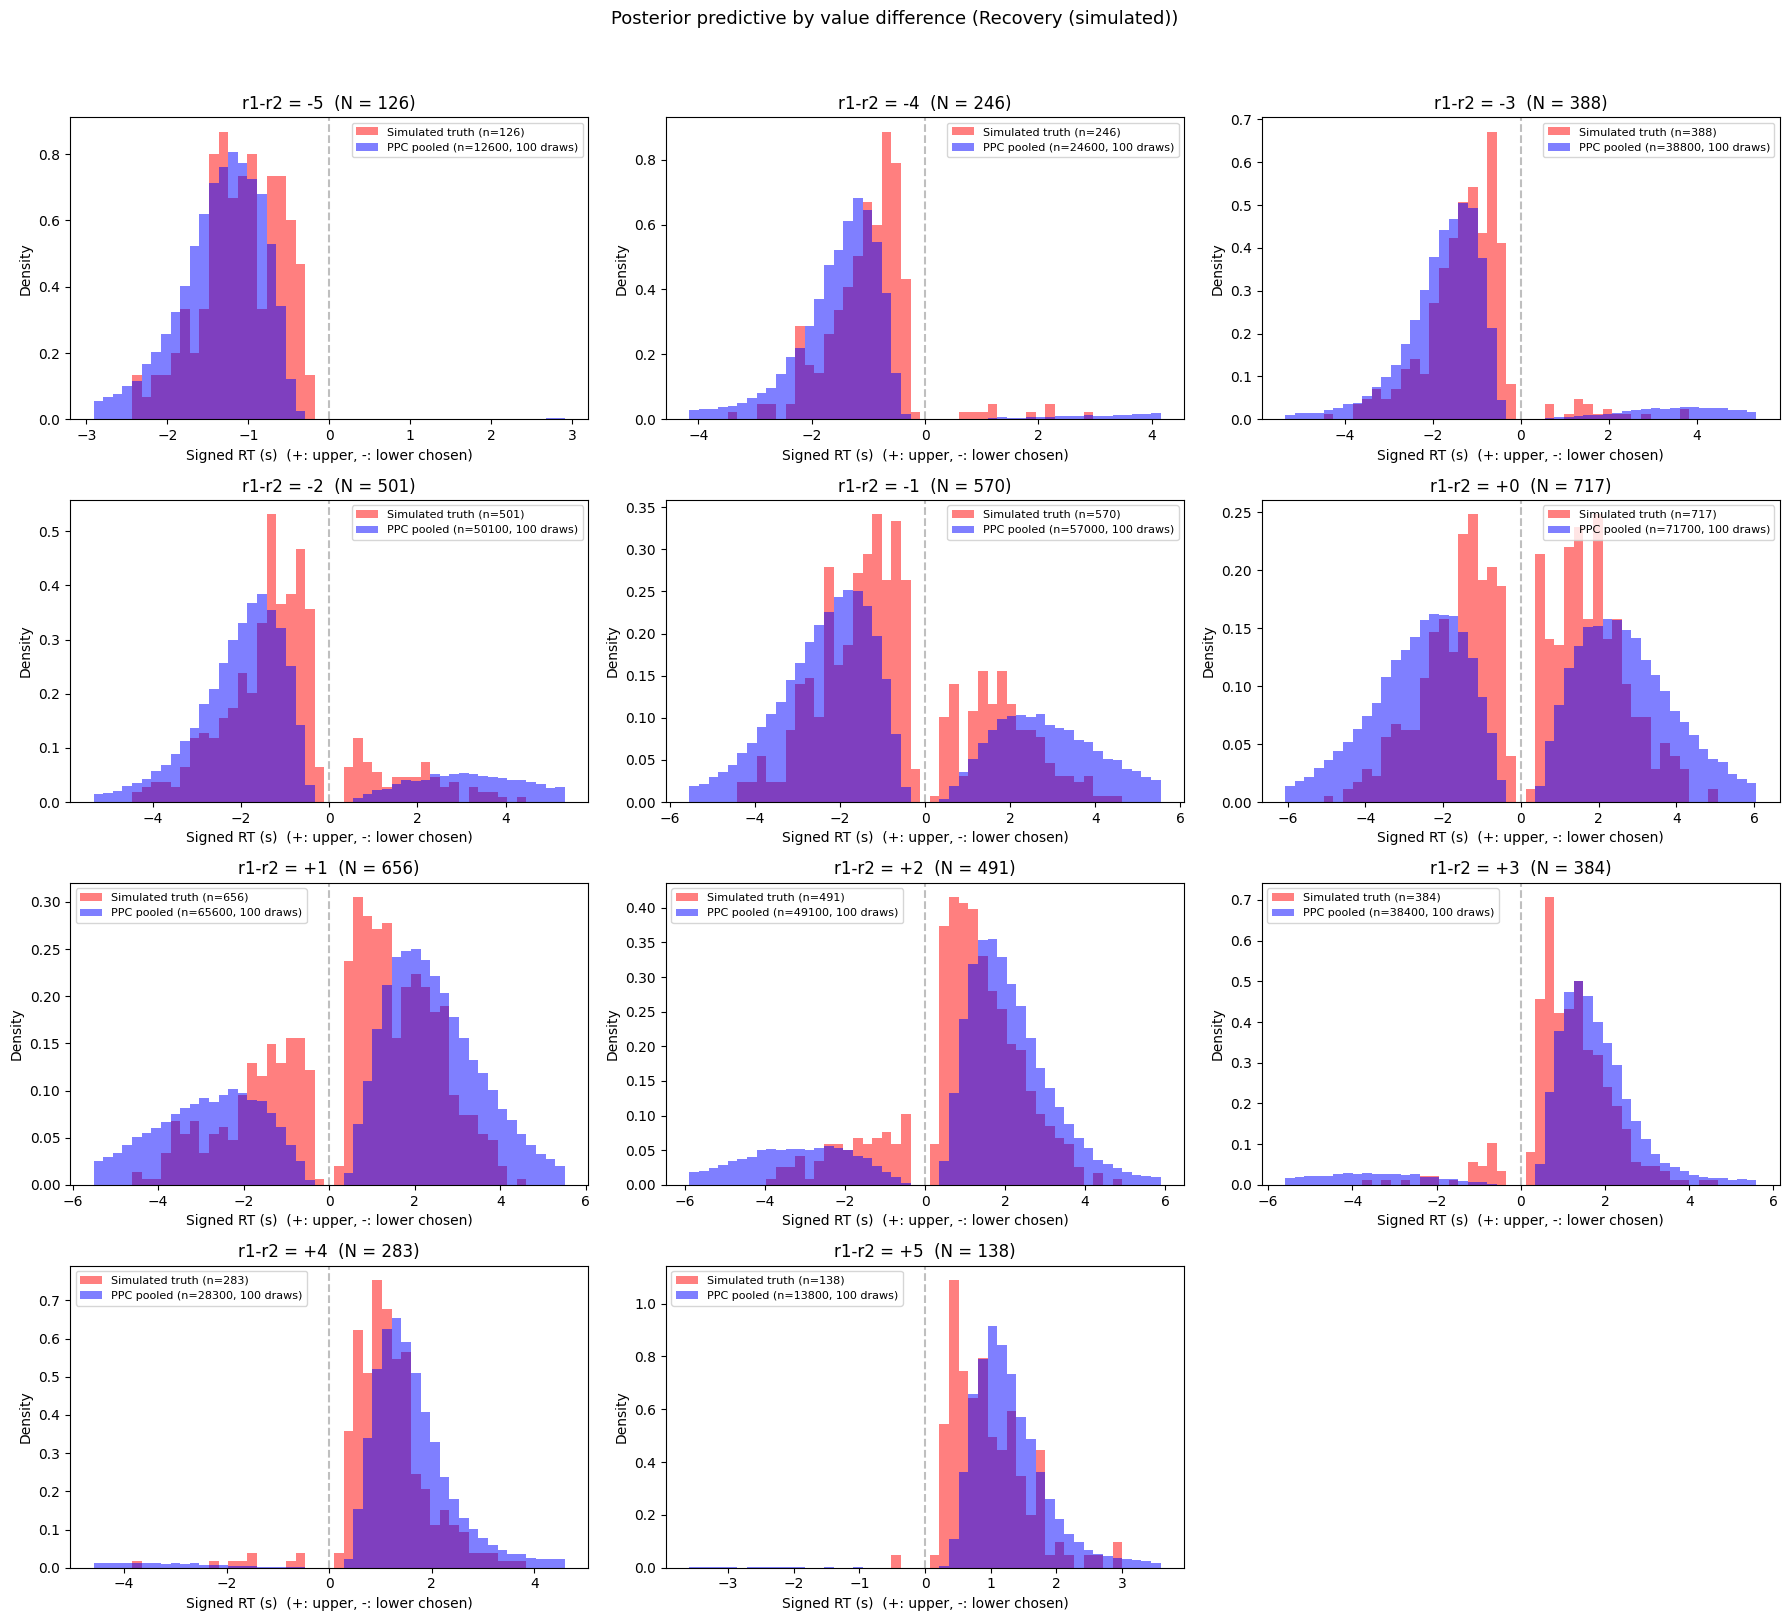

In [27]:
plot_ppc_by_diff(trace_sim, data_sim, 'Recovery (simulated)', max_d=max_d)